<a href="https://colab.research.google.com/github/Putra1688/PCVK25_3G_22/blob/main/Week09_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TUGAS PRAKTIKUM**

## 1- Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2- Import Library

In [3]:
!pip install pytesseract

In [19]:
import cv2 as cv
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

## 3- Buat Global Treshold

(BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV), dengan
threshold= 170

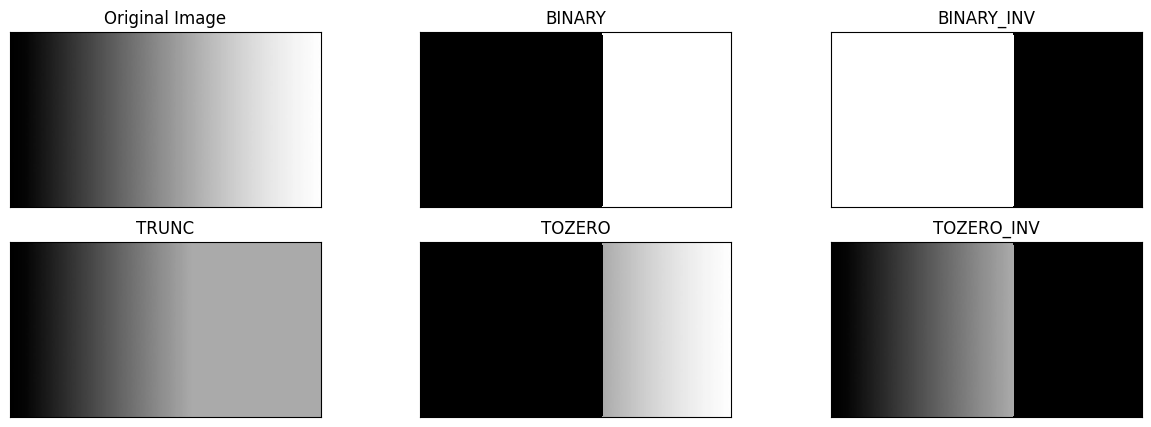

In [8]:
filename = ('/content/drive/MyDrive/PCVK25_3G_22/Week09/gradient.jpg')
img = cv.imread(filename)
thresh1 = cv.imread(filename)
thresh2 = cv.imread(filename)
thresh3 = cv.imread(filename)
thresh4 = cv.imread(filename)
thresh5 = cv.imread(filename)
thresh = 170 #nilai Threshold yang ditentukan
#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
thresh1[img>thresh] = 255 #tanpa library
thresh1[img<=thresh] = 0
#2. thresh2 adalah binary threshold inverse
thresh2 = 255 - thresh1 #tanpa library
#3. Threshold Truncate
thresh3[img>thresh] = thresh #tanpa library
#4. Threshold Tozero
thresh4[img<=thresh] = 0 #tanpa library
#5. Threshold Tozero Inverse
thresh5[img>thresh] = 0 #tanpa library
titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
plt.figure(figsize = (15,5))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

## 4- Otsu Tresholding
 (gunakan image
ktp Riyanto.jpg agar terlihat beda antara hasil otsu’s dengan global threshold biasa)

167


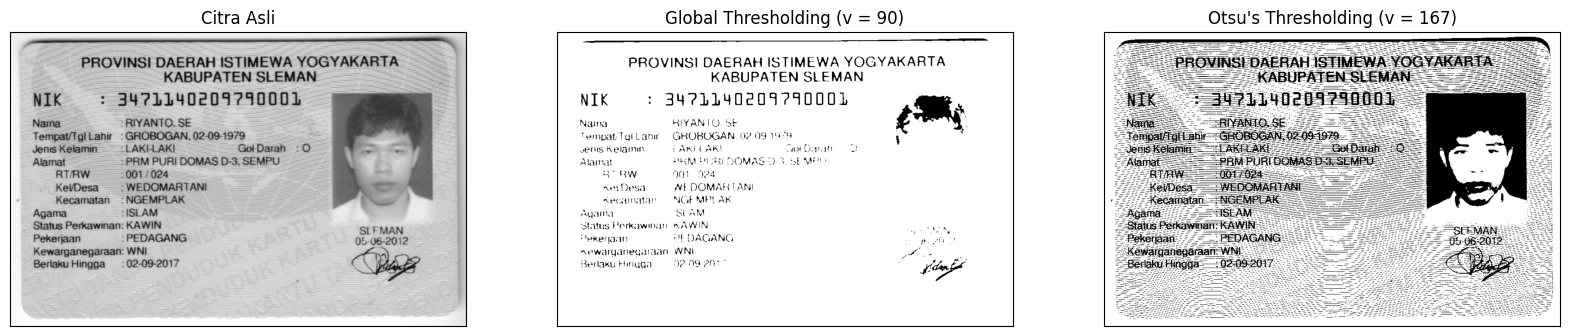

In [12]:
filename = ('/content/drive/MyDrive/PCVK25_3G_22/Week09/ktp.png')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
def otsu(gray):
    pixel_number = gray.shape[0] * gray.shape[1]
    mean_weight = 1.0/pixel_number
    his, bins = np.histogram(gray, np.arange(0,257))
    final_thresh = -1
    final_value = -1
    intensity_arr = np.arange(256)

    # KOREKSI INDENTASI DIMULAI DI SINI
    for t in bins[1:-1]:
        pcb = np.sum(his[:t])
        pcf = np.sum(his[t:])

        # Guard clause to prevent division by zero
        if pcb == 0 or pcf == 0:
            continue

        Wb = pcb * mean_weight
        Wf = pcf * mean_weight

        mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)
        muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)

        # Hitung variance antar kelas (inter-class variance)
        value = Wb * Wf * (mub - muf) ** 2

        # Update nilai ambang batas terbaik
        if value > final_value:
            final_thresh = t
            final_value = value
    final_img = gray.copy()
    print(final_thresh)
    final_img[gray >= final_thresh] = 255 # Pakai >= untuk inklusivitas
    final_img[gray < final_thresh] = 0
    return final_img, final_thresh
otsu_biner, otsu_thresh = otsu(img)
x = ("Otsu's Thresholding (v = ")+str(otsu_thresh)+")"
ret,th1 = cv.threshold(blur,90,255,cv.THRESH_BINARY)
#ret,th2 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)
titles = ['Citra Asli', 'Global Thresholding (v = 90)', x]
citra3 = [blur, th1, otsu_biner]
plt.figure(figsize = (20,15))
for i in range(len(citra3)):
  plt.subplot(1,3,i+1),plt.imshow(citra3[i],'gray')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

## 5- Histogram citra Tersegmentasi

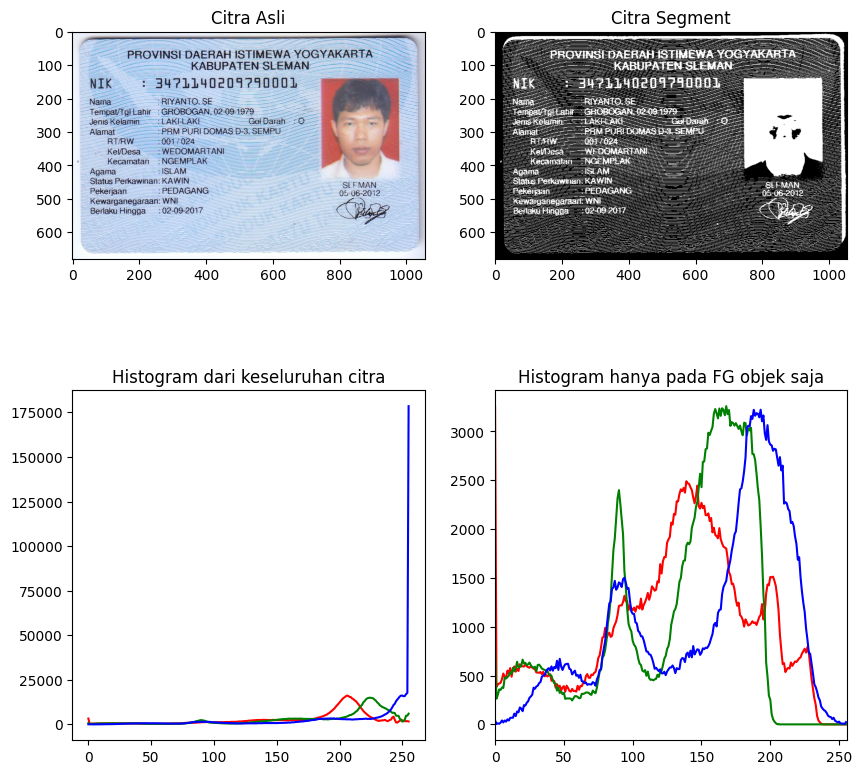

In [11]:
filename = ('/content/drive/MyDrive/PCVK25_3G_22/Week09/ktp.png')
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
ret3,mask = cv.threshold(img_gray,200,255,cv.THRESH_BINARY_INV)
plt.figure(figsize = (10,10))
plt.subplot(2,2,1),plt.imshow(img)
plt.title('Citra Asli')
plt.subplot(2,2,2),plt.imshow(mask, 'gray')
plt.title('Citra Segment')
color = ('r','g','b')
for i,col in enumerate(color):
  hist0 = cv.calcHist([img],[i],None,[256],[0,256])
  plt.subplot(2,2,3),plt.plot(hist0,color = col)
  plt.title('Histogram dari keseluruhan citra')
  hist1 = cv.calcHist([img],[i],mask,[256],[0,256])
  plt.subplot(2,2,4),plt.plot(hist1,color = col)
  plt.title('Histogram hanya pada FG objek saja')
  plt.xlim([0,256])
plt.show()

## 6- Segmentasi Warna pada Image

(<Axes: >, <matplotlib.image.AxesImage at 0x79d7e3533e30>)

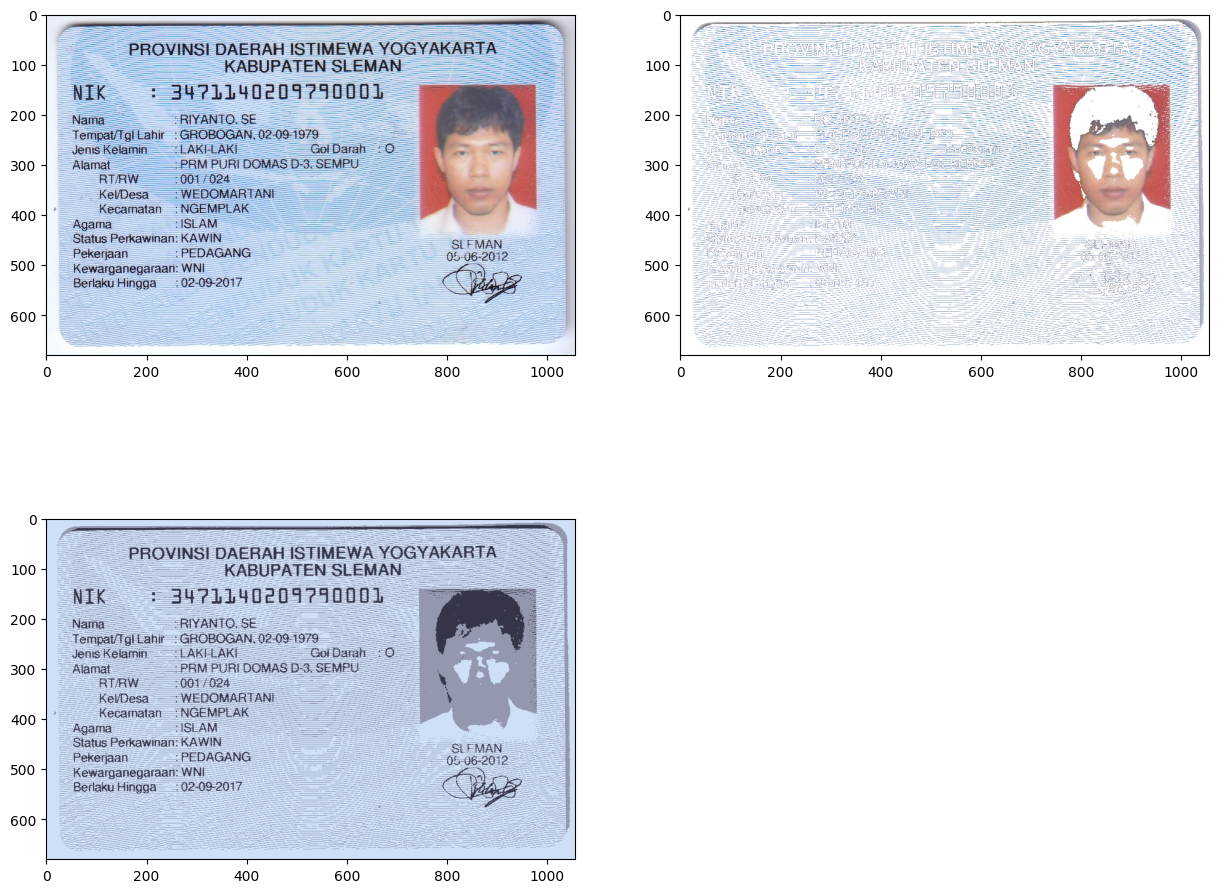

In [18]:
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)
'''
kita akan menggunakan fungsi cv.kmeans() yang meminta array 2D sebagai masukan,
sedangkan image aslinya adalah array 3D
selanjutnya kita perlu melakukan flattening array image masukan
'''
#reshape array ke bentuk 2D
pixel_values = img.reshape((-1, 3))
# convert to float
pixel_values = np.float32(pixel_values)
'''
syarat berhenti iterasi dr KMeans adalah jika centroid sudah tidak terlalu banyak
pergeseran posisi antara interasi sekarang dengan iterasi sebelumnya (konvergen). Karena jumlah data yang besar, maka kita
akan hentikan iterasi saat jumlah iterasi = 100
atau epsilon(selisih antara posisi centroid skrg dgn posisi centroid di iterasi
sebelumnya) < 0.2
'''
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 150, 0.1)
'''
jika diperhatikan pada image asli, terdapat 3 warna utama (hijau, biru, dan
putih/orange). untuk percobaan ini kita akan gunakan
3 cluster untuk image ini
'''
k = 3
_, labels, (centers) = cv.kmeans(pixel_values, k, None, criteria, 10,
cv.KMEANS_RANDOM_CENTERS)
#konversi titik centroid kedalam integer
centers = np.uint8(centers)
#flattening label array
labels = labels.flatten()
#konversi warna pixel asli kewarna dari tiap centroidnya
segmented_image = centers[labels.flatten()]
# reshape ke bentuk image asli
segmented_image = segmented_image.reshape(img.shape)
masked_image = np.copy(img)
masked_image0 = masked_image.reshape((-1, 3))
masked_image0[labels != 1] = [255, 255, 255]
masked_image0 = masked_image0.reshape(img.shape)

plt.figure(figsize = (15,12))
plt.subplot(2,2,1),plt.imshow(img)
plt.subplot(2,2,2),plt.imshow(masked_image0)
plt.subplot(2,2,3),plt.imshow(segmented_image)

## 7- Konversi Gambar KTP menjadi teks yang dapat mengenali tulisan

dict_keys(['level', 'page_num', 'block_num', 'par_num', 'line_num', 'word_num', 'left', 'top', 'width', 'height', 'conf', 'text'])


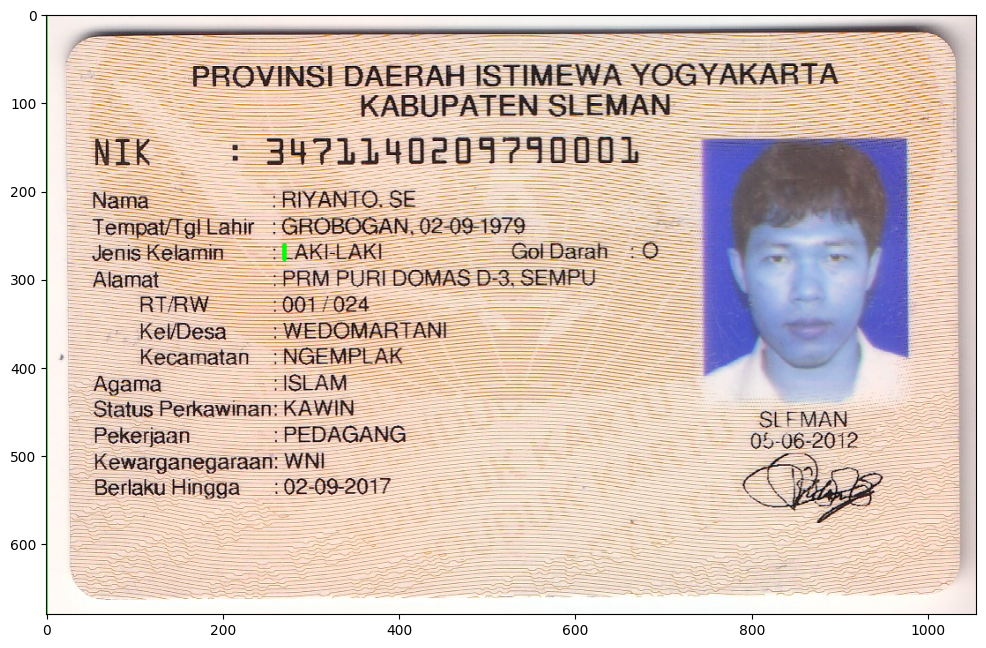

In [34]:
def display(img,cmap='gray'):
  fig = plt.figure(figsize=(12,10))
  ax = fig.add_subplot(111)
  ax.imshow(img,cmap='gray')

from pytesseract import Output
img = cv2.imread('/content/drive/MyDrive/PCVK25_3G_22/Week09/ktp.png')
d = pytesseract.image_to_data(img, output_type=Output.DICT)
print(d.keys())

n_boxes = len(d['text'])
for i in range(n_boxes):
  if int(d['conf'][i]) > 60:
    (x, y, w, h) = (d['left'][i], d['top'][i], d['width'][i], d['height'][i])
    img = cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
display(img)

In [29]:
# Instal paket data bahasa Indonesia
!sudo apt install tesseract-ocr-ind

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-ind
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 537 kB of archives.
After this operation, 1,138 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-ind all 1:4.00~git30-7274cfa-1.1 [537 kB]
Fetched 537 kB in 1s (665 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package tesseract-ocr-ind.
(Reading databa

em

PROVINSI DAERAH ISTIMEWA YOGYAKARTA
KABUPATEN SLEMAN

 

NIK : 34711140209790001

Nama :RIYANTO. SE

Tempat/Tgl Lahir : GROBOGAN. 02-09-1979

Jenis Kelamin : LAKI-LAKI Gol Darah : 0

Alamat PRM PURI DOMAS D-3. SEMPU
RTRW 1001 1024

Kel/Desa : WEDOMARTANI!
Kecamatan : NGEMPLAK

Agama "ISLAM
Status Bean KAWIN SLEMAN
Pekerjaan : PEDAGANG 05-06-2012

Kewarganegaraan: WNI HI —
Berlaku Hingga :02-09-2017 NIA

   
 

 



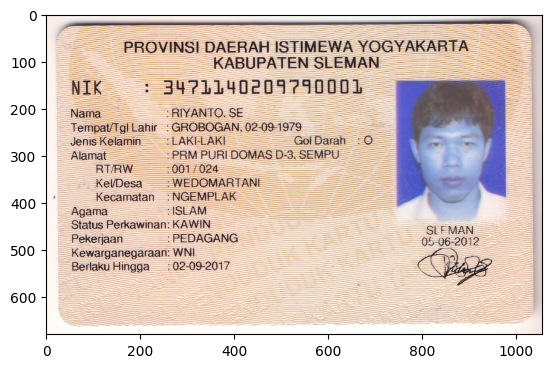

In [30]:
plt.imshow(img)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
th, threshed = cv2.threshold(gray, 127, 255, cv2.THRESH_TRUNC)
text1 = pytesseract.image_to_data(threshed,output_type='data.frame')
text2 = pytesseract.image_to_string(threshed, lang="ind")
print(text2)
text = text1[text1.conf != -1]
lines = text.groupby('block_num')['text'].apply(list)
conf = text.groupby(['block_num'])['conf'].mean()

## 8- Implementasi hasil citra yang telah diproses dengan GLOBAL THRESHOLDING
hasilnya diproses untuk membaca teks yang terdapatpada KTP.

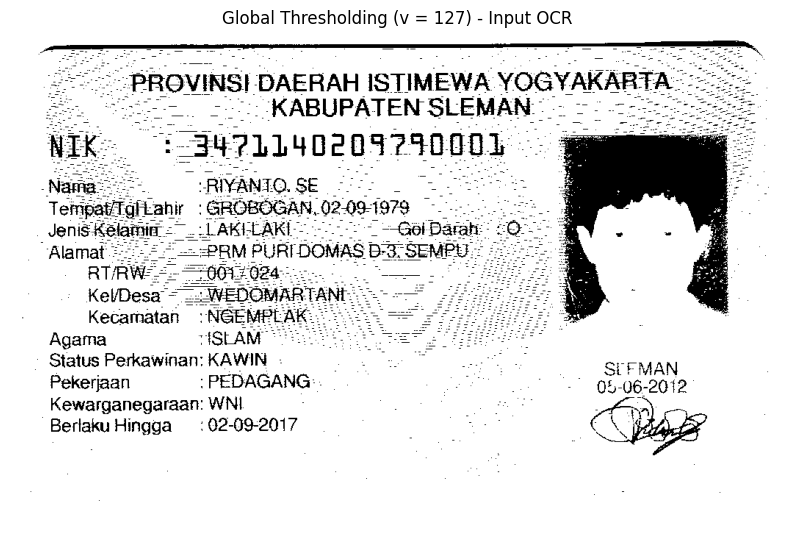

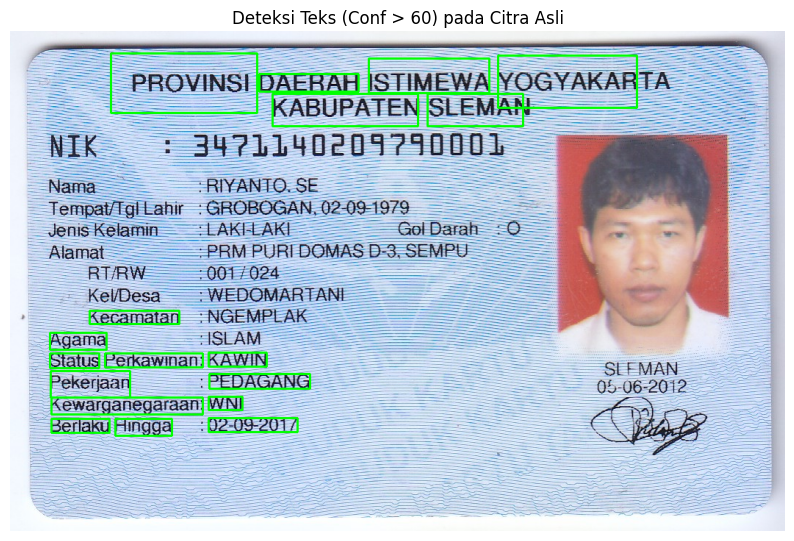

Hasil OCR (Global Thresholding v=127):
A PROVINS! DAERAH ISTIMEWA YOGYAKAR
KABUPATEN SLEMAN = -

aunuo20529000)

Kecamatan
Agama
Status Perkawinan: KAWIN Lot i . StFMAN
Pekerjaan : PEDAGANG : 05-06-2012
Kewarganegaraan: WNI. . °
Berlaku Hingga | 02-09-2017 . oH

N

     



In [36]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import pandas as pd
# from PIL import Image # PIL tidak diperlukan di sini

# Tentukan path file Anda
filename = '/content/drive/MyDrive/PCVK25_3G_22/Week09/ktp.png'

# --- 1. Fungsi Display ---
def display(img, title="Image"):
    """Fungsi pembantu untuk menampilkan citra dalam Matplotlib"""
    # cv2 memuat BGR, Matplotlib butuh RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.title(title)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

# --- 2. Pemuatan dan Pra-pemrosesan Citra ---
# Muat citra asli
img_asli = cv2.imread(filename)

# Ubah ke grayscale (diperlukan untuk thresholding)
gray = cv2.cvtColor(img_asli, cv2.COLOR_BGR2GRAY)

# --- 3. Implementasi Global Thresholding (Misalnya, Nilai Ambang Batas 127) ---
# Terapkan Global Thresholding.
# cv2.THRESH_BINARY mengubah piksel > 127 menjadi 255 (putih) dan lainnya menjadi 0 (hitam).
nilai_ambang = 127
ret, img_thresholded = cv2.threshold(gray, nilai_ambang, 255, cv2.THRESH_BINARY)

# Untuk tampilan yang lebih baik pada OCR, terkadang citra biner perlu di-invert
# img_thresholded_inv = cv2.bitwise_not(img_thresholded)

# --- 5. Visualisasi Hasil ---
# Tampilkan citra biner yang digunakan untuk OCR
display(cv2.cvtColor(img_thresholded, cv2.COLOR_GRAY2BGR), # Ubah kembali ke 3 channel (BGR) untuk display
        f"Global Thresholding (v = {nilai_ambang}) - Input OCR")

# Visualisasi deteksi (opsional: menggambar kotak pada citra asli)
img_kotak = img_asli.copy()
n_boxes = len(data_dict['text'])
conf_min = 60 # Ambang batas kepercayaan

for i in range(n_boxes):
    # Pastikan conf > ambang batas, dan teks tidak kosong
    if data_dict['text'][i].strip() != '' and int(data_dict['conf'][i]) > conf_min:
        (x, y, w, h) = (data_dict['left'][i], data_dict['top'][i], data_dict['width'][i], data_dict['height'][i])
        img_kotak = cv2.rectangle(img_kotak, (x, y), (x + w, y + h), (0, 255, 0), 2)

display(img_kotak, f"Deteksi Teks (Conf > {conf_min}) pada Citra Asli")

# --- 4. Membaca Teks (OCR) dari Citra Hasil Thresholding ---
# Gunakan citra hasil thresholding (binary image) untuk OCR
# Note: Jika Anda berhasil menginstal ind.traineddata, tambahkan lang='ind'
try:
    # Membaca seluruh teks sebagai satu string
    text_string = pytesseract.image_to_string(img_thresholded)

    # Membaca data secara rinci (untuk melihat confidence)
    data_dict = pytesseract.image_to_data(img_thresholded, output_type=pytesseract.Output.DICT)

    print("=" * 40)
    print(f"Hasil OCR (Global Thresholding v={nilai_ambang}):")
    print("=" * 40)
    print(text_string)
    print("=" * 40)

except pytesseract.TesseractError as e:
    print("\n[ERROR] Gagal menjalankan Tesseract.")
    print("Pastikan Tesseract OCR engine sudah terinstal dan path datanya benar.")
    print(f"Detail Error: {e}")